zlogvar - Tensor("Placeholder_1:0", shape=(None, 2), dtype=float32), z_mean - Tensor("Placeholder:0", shape=(None, 2), dtype=float32)
zlogvar - Tensor("Placeholder_1:0", shape=(None, 2), dtype=float32), epsilon - Tensor("random_normal:0", shape=(None, 2), dtype=float32), z_mean - Tensor("add:0", shape=(None, 2), dtype=float32)
Creating VAE model...
Training VAE...
Epoch 1/7
zlogvar - Tensor("encoder_1/z_log_var_1/BiasAdd:0", shape=(None, 2), dtype=float32), z_mean - Tensor("encoder_1/z_mean_1/BiasAdd:0", shape=(None, 2), dtype=float32)
zlogvar - Tensor("encoder_1/z_log_var_1/BiasAdd:0", shape=(None, 2), dtype=float32), epsilon - Tensor("encoder_1/sampling_1_1/random_normal:0", shape=(None, 2), dtype=float32), z_mean - Tensor("encoder_1/sampling_1_1/add:0", shape=(None, 2), dtype=float32)
zlogvar - Tensor("encoder_1/z_log_var_1/BiasAdd:0", shape=(None, 2), dtype=float32), z_mean - Tensor("encoder_1/z_mean_1/BiasAdd:0", shape=(None, 2), dtype=float32)
zlogvar - Tensor("encoder_1/z_log_va

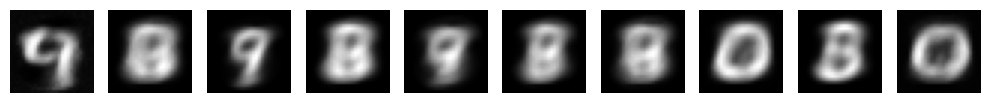

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, Flatten, Reshape, Layer
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess MNIST data
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 28, 28, 1))

# Network parameters
input_shape = (28, 28, 1)
batch_size = 128
latent_dim = 2
intermediate_dim = 512
epochs = 7

class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        print(f'zlogvar - {z_log_var}, z_mean - {z_mean}')
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        z_mean = z_mean + tf.exp(0.5 * z_log_var) * epsilon
        print(f'zlogvar - {z_log_var}, epsilon - {epsilon}, z_mean - {z_mean}')
        return z_mean

# Encoder
encoder_inputs = Input(shape=input_shape)
x = Flatten()(encoder_inputs)
x = Dense(intermediate_dim, activation='relu')(x)
z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

# Decoder
decoder_inputs = Input(shape=(latent_dim,))
x = Dense(intermediate_dim, activation='relu')(decoder_inputs)
x = Dense(784, activation='sigmoid')(x)
decoder_outputs = Reshape((28, 28, 1))(x)
decoder = Model(decoder_inputs, decoder_outputs, name='decoder')

class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name='total_loss')
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = tf.keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # Encoder output
            z_mean, z_log_var, z = self.encoder(data)
            # Reconstruction
            reconstruction = self.decoder(z)

            # Flatten input and reconstruction for binary crossentropy
            flat_data = tf.reshape(data, (-1, 784))
            flat_reconstruction = tf.reshape(reconstruction, (-1, 784))

            # Reconstruction loss (fixed axis handling)
            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(
                    flat_data,
                    flat_reconstruction
                )
            ) * 784

            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total loss
            total_loss = reconstruction_loss + kl_loss

        # Compute gradients
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

# Create and compile VAE
print("Creating VAE model...")
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))

# Train VAE
print("Training VAE...")
vae.fit(x_train,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True)

def generate_digits(decoder, n=10):
    """Generate n new digits using the decoder"""
    z_sample = np.random.normal(size=(n, latent_dim))
    x_decoded = decoder.predict(z_sample)
    return x_decoded

# After training the VAE, you can use it like this:
print("\nGenerating new digits...")
new_digits = generate_digits(decoder, 10)  # Generates 10 new digits

# To visualize the generated digits
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(new_digits[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()